In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'smarties.png'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(356, 413, 3)

In [3]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

restrictive_lower, restrictive_upper = np.array([66, 240, 250]), np.array([68, 255, 255])
final_lower, final_upper = np.array([40, 80, 50]), np.array([85, 255, 255])

restrictive_mask = cv2.inRange(hsv, restrictive_lower, restrictive_upper)
final_mask = cv2.inRange(hsv, final_lower, final_upper)
extracted = cv2.bitwise_and(img, img, mask=final_mask)

print('restrictive mask pixels:', cv2.countNonZero(restrictive_mask))
print('final mask pixels:', cv2.countNonZero(final_mask))

restrictive mask pixels: 2106
final mask pixels: 5362


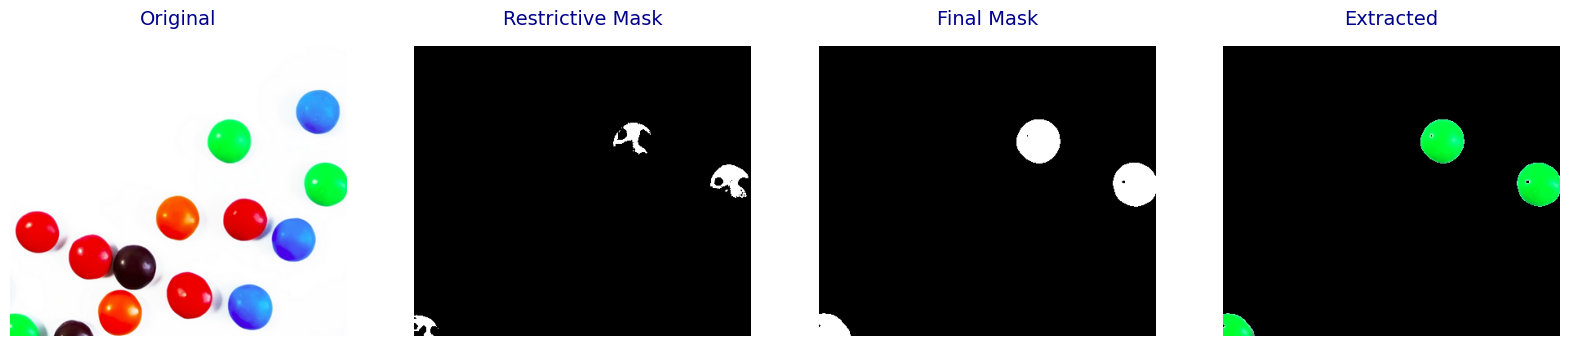

In [4]:
panels = [('Original', img), ('Restrictive Mask', restrictive_mask), ('Final Mask', final_mask), ('Extracted', extracted)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task4_mask.png', final_mask)
cv2.imwrite('output/task4_extracted.png', cv2.cvtColor(extracted, cv2.COLOR_RGB2BGR))

True

Restrictive mask (H 66-68, S 240-255, V 250-255) gets 2106 pixels. Final mask (H 40-85, S 80-255, V 50-255) gets 5362. The restrictive one only covers part of each green candy.

The restrictive mask fails because one candy has many different HSV values from shading and highlights. A very narrow range only keeps the pixels that look like the brightest part. The final range is wider so it gets the whole candy, and the red, blue and brown ones are still left out because their hue is different.